# Electrochemical Impedance Spectroscopy

This example shows you how to perform Electrochemical Impedance Spectroscopy (EIS) measurements with the IM7 potentiostat using the [zahner_link](https://doc.zahner.de/im7/apis/zahner_link/python/) library.
We'll cover several common EIS measurement scenarios and demonstrate how to access and visualize the data.

This notebook includes:
* **Basic Setup:** Connecting to the IM7 and initializing the potentiostat.
* **Automated EIS Measurement:** Running EIS with automatically generated frequency points using [EisGenerateJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisGenerateJob).
* **Custom EIS Frequency Points:** There are two approaches to creating custom EIS with custom frequency points:
  *   Using [EisParametersFrequencyTableEntry](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisParametersFrequencyTableEntry) objects with [EisFrequencyTableJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisFrequencyTableJob).
  *   Using Python dictionaries with [EisFrequencyTableJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisFrequencyTableJob).
* **Parameter-Dependent Impedance:** Measuring impedance at a single frequency while varying DC bias current in galvanostatic mode (useful for diode characteristic curves).
* **Data Access:** Retrieving frequencies, complex impedance values, DC voltage/current from the measurement results.
* **Visualization:** Creating plots of the EIS and impedance vs. parameter data.
* **Data Export:** Saving measurement data to Zahner XML format for use with other tools.

Basic procedures like [DC calibration](https://doc.zahner.de/im7/faq/index.html#warm-up-dc-calibration) after warm-up are not covered in this example.

We'll start by importing the necessary libraries and defining a helper function for plotting EIS.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import numpy as np
import zahner_link as zl


def plot_spectra(data: zl.EisDataset):
    frequencies = data.get_frequencies()
    impedances = data.get_impedance_data().get_calculated_complex_impedance_track()
    fig, (impedance_ax) = plt.subplots(
        1,
        1,
    )
    phase_ax = impedance_ax.twinx()

    (impedance_line,) = impedance_ax.loglog(
        frequencies,
        np.absolute(impedances),
        marker="x",
        color="blue",
        label="Impedance",
    )

    (phase_line,) = phase_ax.semilogx(
        frequencies,
        np.angle(impedances, deg=True),
        marker="x",
        color="red",
        label="Phase",
    )

    impedance_ax.yaxis.set_major_formatter(EngFormatter(unit=r"$\Omega$"))
    impedance_ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    impedance_ax.set_ylabel(r"|Z|")
    impedance_ax.grid(linestyle="dashed", linewidth=0.2)
    margin = 0.01
    impedance_ax.margins(margin)

    phase_ax.yaxis.set_major_formatter(EngFormatter(unit="$°$", sep=""))
    phase_ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    phase_ax.set_ylabel("Phase")
    phase_ax.grid(linestyle="dashed", linewidth=0.2)
    phase_ax.margins(margin)
    impedance_ax.legend(handles=[impedance_line, phase_line])

    fig.set_size_inches(18, 10)
    fig.tight_layout()
    plt.show()


link = zl.ZahnerLinkExc("10.10.253.150", "1994")
error: zl.ErrorObject = link.connect()

if not error:
    print("connected successfully")
else:
    print(f"failed to connect, status: {error.get_error_code_enum()}, message: {error.get_message_formatted()}")

switch_on_job = zl.control.SwitchOnJob(
    potentiostat="MAIN:1:POT",
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=0,
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat="MAIN:1:POT")
link.do_job(switch_on_job)

connected successfully


## EIS with Automatically Generated Frequency Points

Now we'll run an EIS measurement in potentiostatic mode (since we've already switched the potentiostat on in this mode). We'll use [EisGenerateJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisGenerateJob) which automatically generates the frequency points across the spectrum.

The measurement sweeps through frequencies in this order: from `start_frequency` up to `max_frequency`, then down to `min_frequency`. For frequency resolution, the system uses `points_per_decade_upper` above 66 Hz and `points_per_decade_lower` at `min_frequency` decreasing below 66 Hz.

The measurement parameters include:

- `pre_waves` and `pre_duration`: Control the settling period before taking measurements
- `meas_waves` and `meas_duration`: Control the actual measurement period

For these parameters, `waves` specifies the minimum number of sine waves to measure, while `duration` sets a time limit. The system will always complete the minimum number of waves, and will continue measuring until the duration is reached (if longer than the minimum waves).

Examples:
* 1 Hz measurement frequency, meas_duration = 9, meas_waves = 3 ➡️ 9 waves are measured  
* 1 Hz measurement frequency, meas_duration = 0, meas_waves = 3 ➡️ 3 waves are measured

This setup is useful because at high frequencies, it's better to measure by duration, while at low frequencies, controlling the number of waves is more practical.

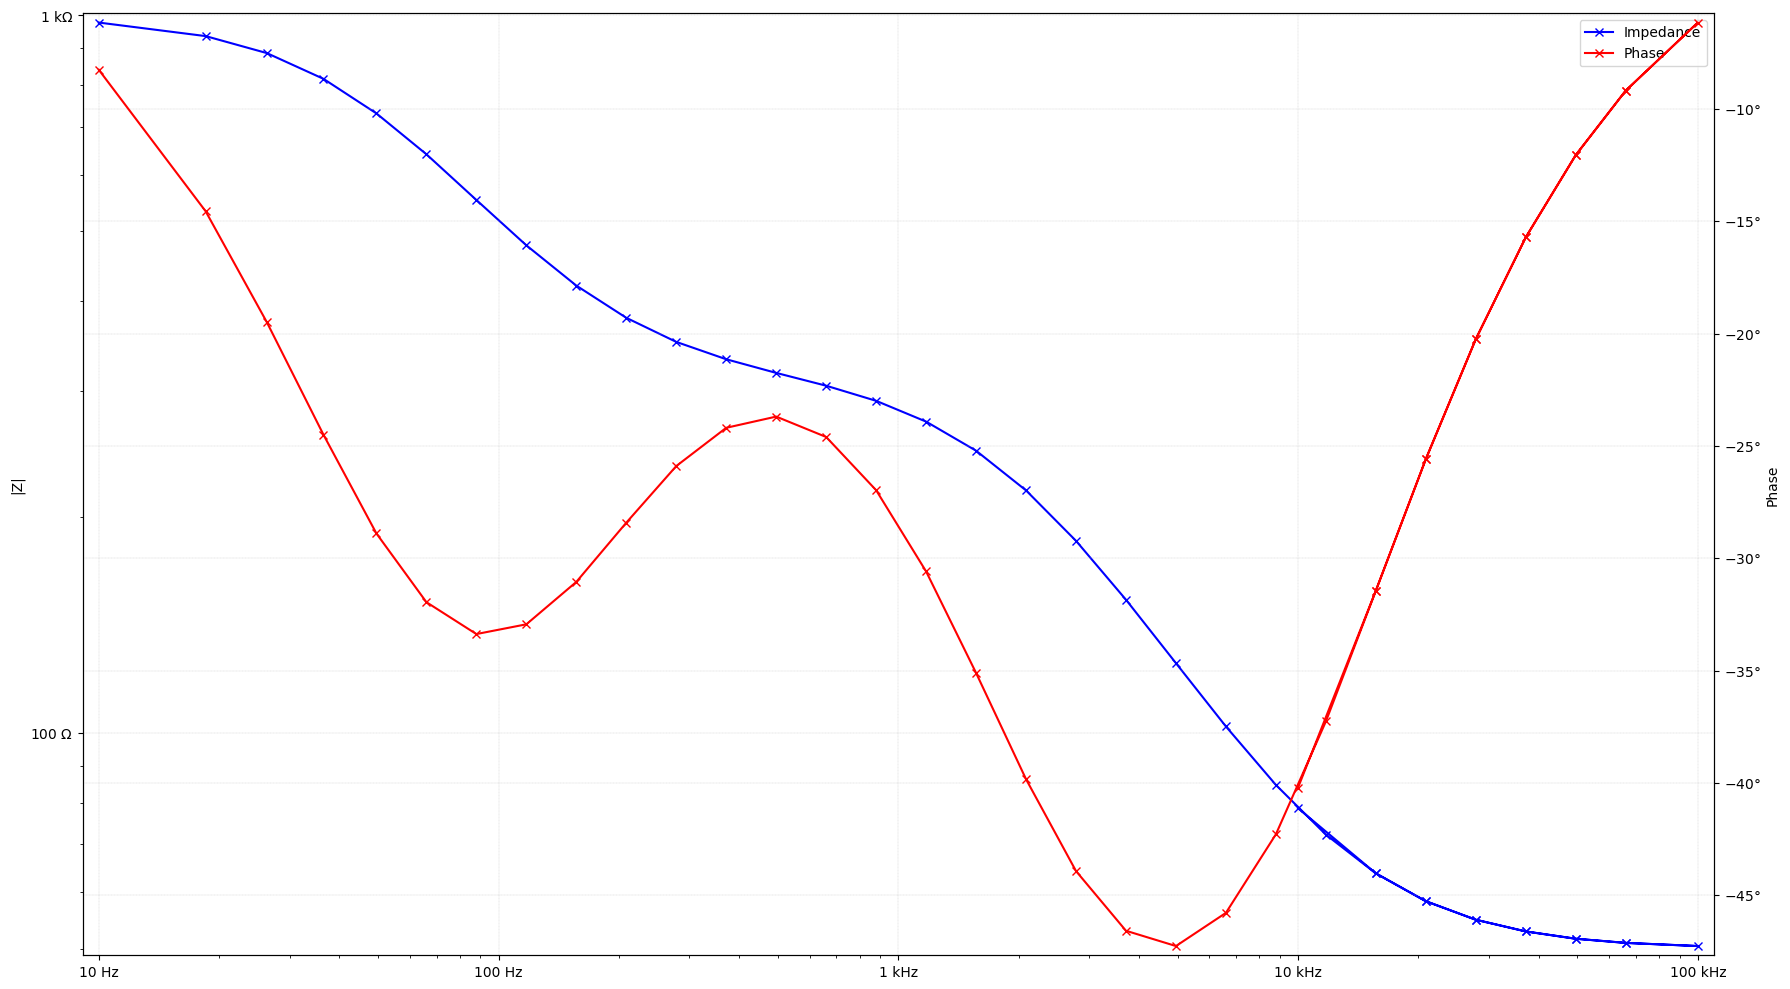

0

In [2]:
eis_generate_job = zl.meas.EisGenerateJob(
    bias=0,
    min_frequency=10,
    max_frequency=1e5,
    start_frequency=10e3,
    points_per_decade_upper=8,
    points_per_decade_lower=5,
    pre_duration=0,
    pre_waves=1,
    meas_duration=0.1,
    meas_waves=4,
    amplitude=1e-2,
)
link.do_job(eis_generate_job)
eis_generate_data = link.get_job_result_data(eis_generate_job)
plot_spectra(eis_generate_data)

xml_measurement = zl.xml.Measurement(eis_generate_data)
exporter = zl.xml.ZXmlExporter()
exporter.set_compact_xml(False)
exporter.save_as_file_standalone(xml_measurement, "eis_generate_job.zmx")

## Custom EIS Spectrum Using Objects

Instead of using automatically generated frequencies, we can manually define the spectrum using [EisFrequencyTableJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisFrequencyTableJob). This approach allows us to specify different settings for each frequency point, which is particularly useful when you need varying amplitudes for different frequencies as shown in the example below.

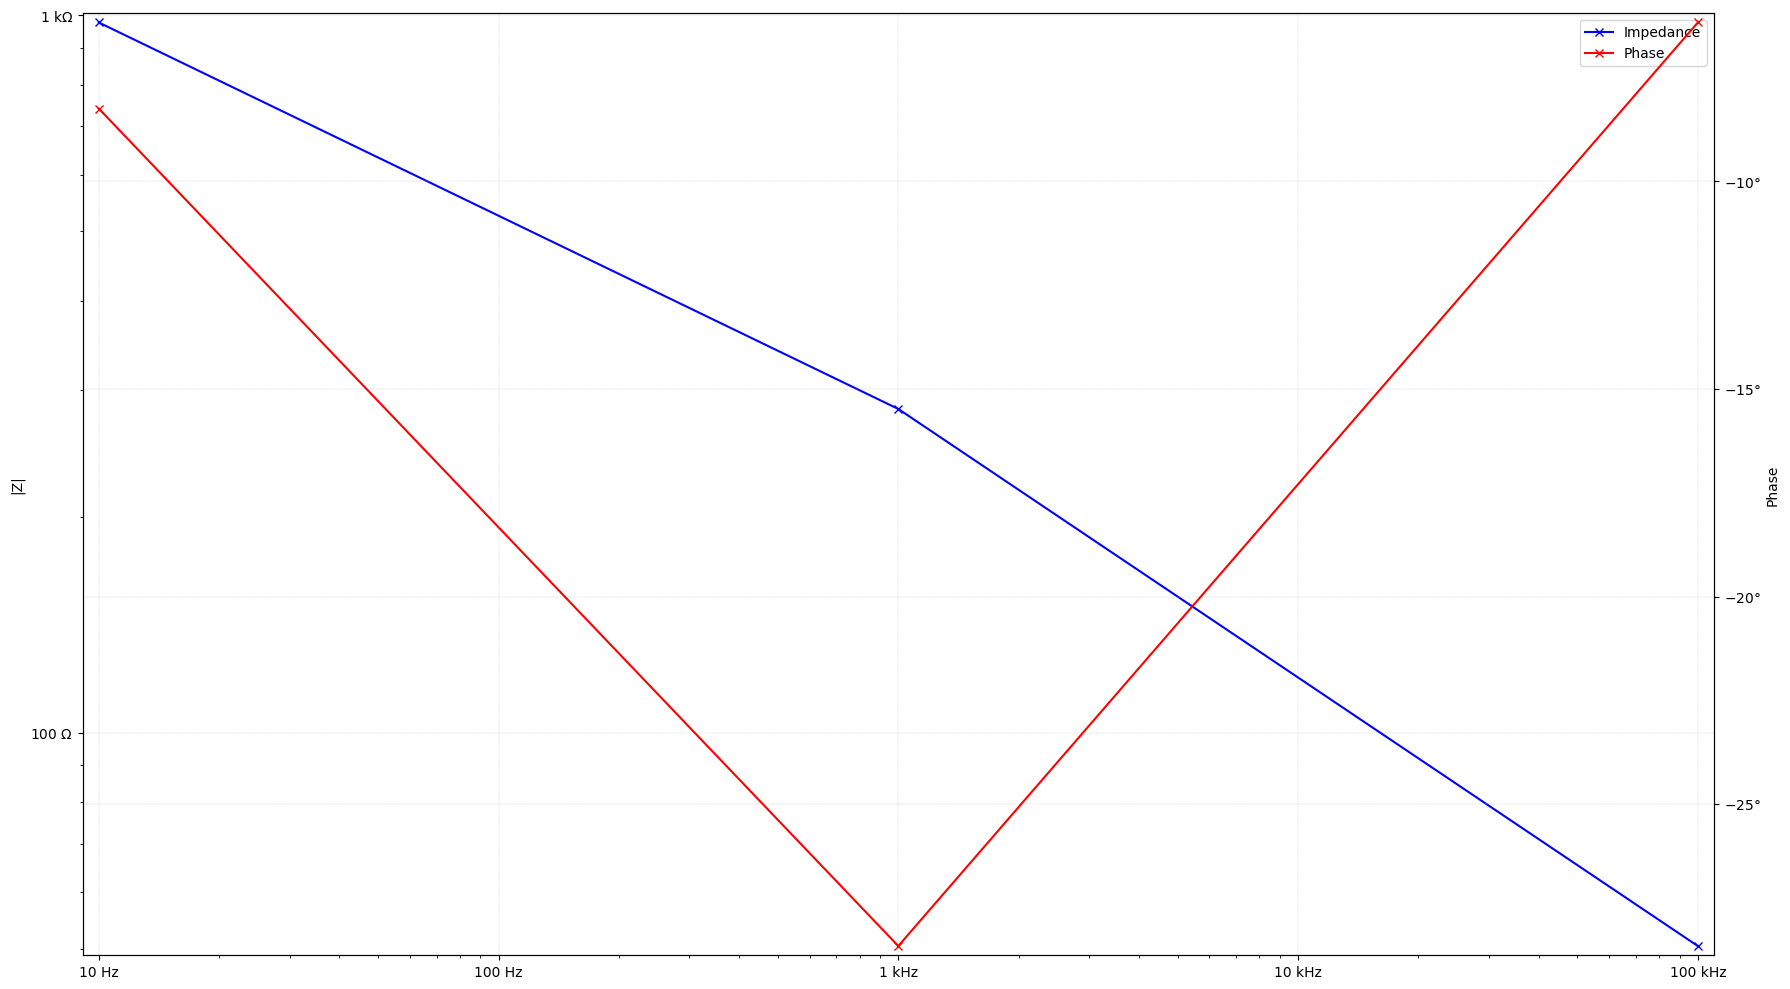

0

In [3]:
eis_table_job = zl.meas.EisFrequencyTableJob(
    bias=0.0,
    spectrum=[
        zl.meas.EisParametersFrequencyTableEntry(
            frequency=10,
            amplitude=10e-3,
            pre_duration=0.1,
            pre_waves=1,
            meas_duration=0.5,
            meas_waves=3,
        ),
        zl.meas.EisParametersFrequencyTableEntry(
            frequency=1e3,
            amplitude=20e-3,
            pre_duration=0.1,
            pre_waves=1,
            meas_duration=0.5,
            meas_waves=3,
        ),
        zl.meas.EisParametersFrequencyTableEntry(
            frequency=100e3,
            amplitude=30e-3,
            pre_duration=0.1,
            pre_waves=1,
            meas_duration=0.5,
            meas_waves=3,
        ),
    ],
)
link.do_job(eis_table_job)
eis_table_data = link.get_job_result_data(eis_table_job)
plot_spectra(eis_table_data)

xml_measurement = zl.xml.Measurement(eis_table_data)
exporter.save_as_file_standalone(xml_measurement, "eis_table_job.zmx")

## Custom EIS Spectrum Using Python Dictionaries

For even more flexibility, [EisFrequencyTableJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisFrequencyTableJob) also accepts Python dictionaries as input. This approach can be combined with Python's [list comprehensions](https://docs.python.org/3/tutorial/datastructures.html#list-comprehensions) to dynamically generate the measurement points.

In the example below, we create frequency points from predefined lists of frequencies and amplitudes using a list comprehension.

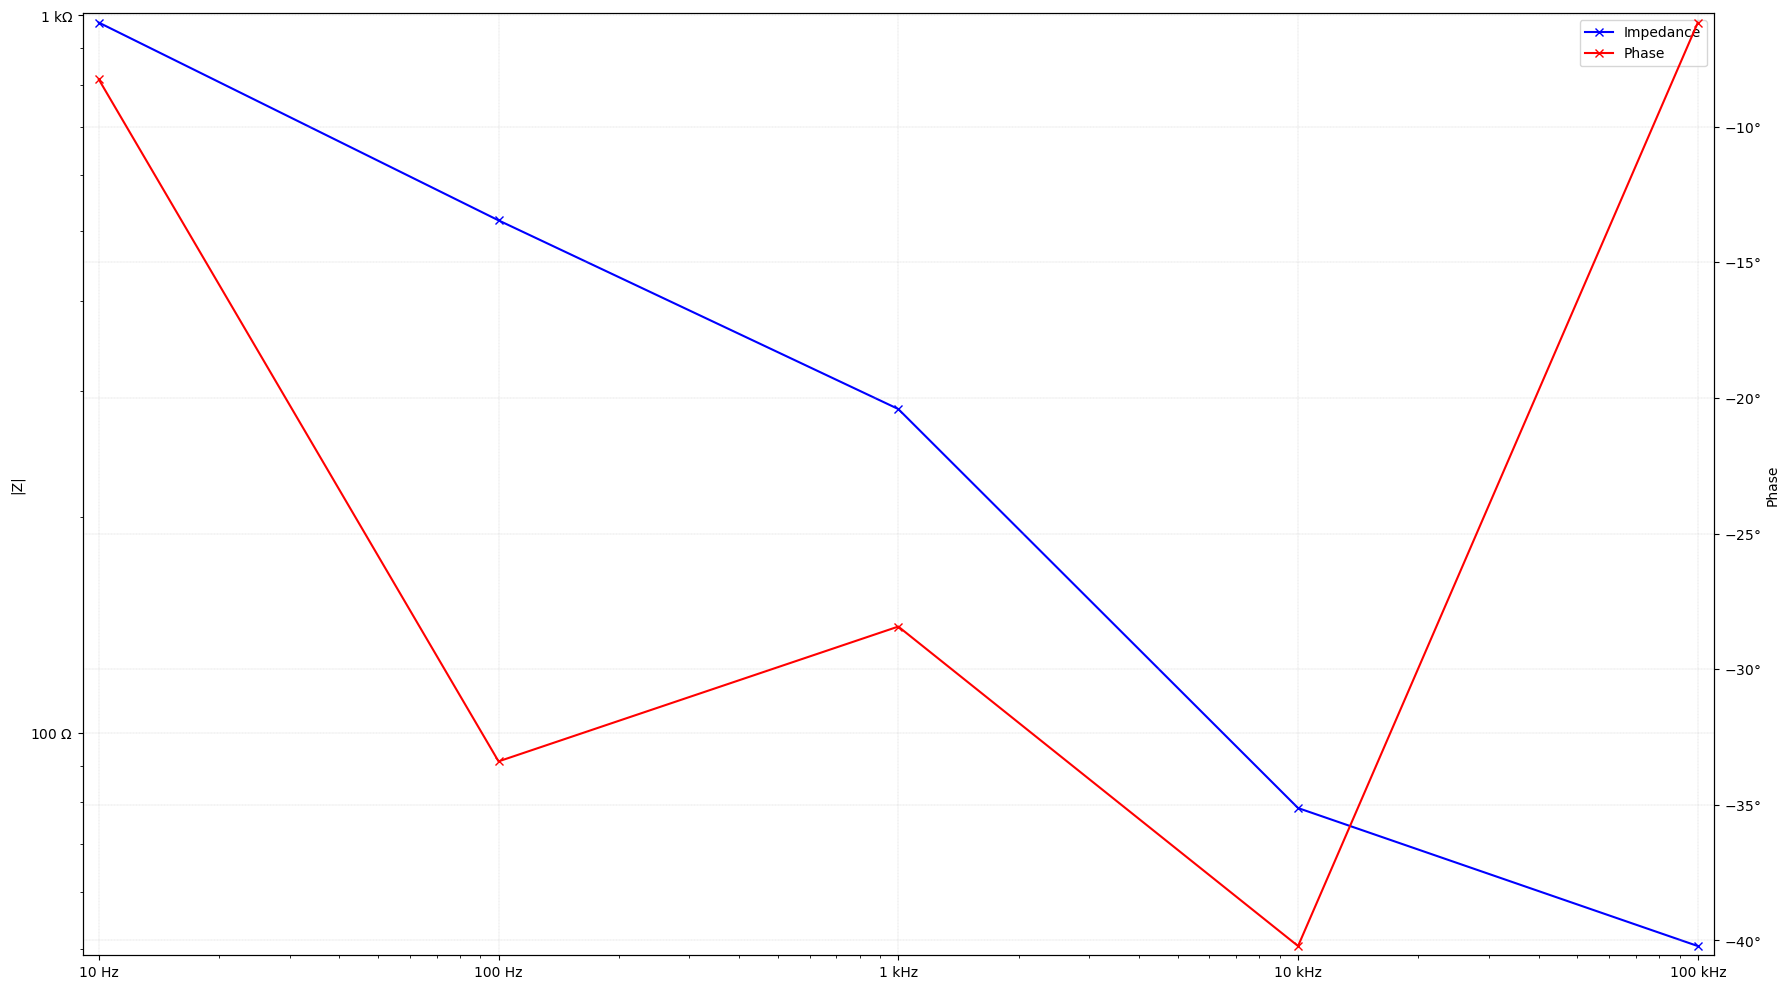

0

In [4]:
frequencies_to_measure = [10, 1e2, 1e3, 1e4, 1e5]
amplitudes_to_measure = [10e-3, 5e-3, 10e-3, 100e-3, 100e-3]
eis_dict_table_job = zl.meas.EisFrequencyTableJob(
    {
        "bias": 0.0,
        "spectrum": [
            {
                "frequency": freq,
                "amplitude": ampl,
                "pre_duration": 0.1,
                "pre_waves": 1,
                "meas_duration": 0.5,
                "meas_waves": 3,
            }
            for freq, ampl in zip(frequencies_to_measure, amplitudes_to_measure)
        ],
    }
)
link.do_job(eis_dict_table_job)
link.do_job(switch_off_job)
eis_dict_table_data = link.get_job_result_data(eis_dict_table_job)
plot_spectra(eis_dict_table_data)

xml_measurement = zl.xml.Measurement(eis_dict_table_data)
exporter.save_as_file_standalone(xml_measurement, "eis_dict_table_job.zmx")

## Single Frequency Impedance vs Parameter Study

Here we'll demonstrate how to measure impedance at a single frequency while varying another parameter - in this case, the DC bias current through a pair of anti-parallel diodes.

First, we switch from potentiostatic to galvanostatic mode. Then we create a logarithmically spaced array ([np.logspace](https://numpy.org/doc/2.3/reference/generated/numpy.logspace.html)) of current values (both positive and negative) and measure the impedance at each current setpoint.

By measuring at a single frequency (100 Hz) while sweeping the bias current, we can observe how the impedance changes with the diode's operating point. This is a powerful technique for characterizing nonlinear devices.

In [5]:
switch_on_job.parameters.coupling = zl.PotentiostatCoupling.GALVANOSTATIC
bias = 0.1
switch_on_job.parameters.bias = bias
link.do_job(switch_on_job)

eis_same_freq_data = zl.EisDataset()
xml_measurement = zl.xml.Measurement()

positive = np.logspace(np.log10(0.001), np.log10(2), 21)  # 21 points from 0.001 to 2.0
negative = -np.flip(positive)  # Mirror the positive values and negate them
biases = np.sort(np.concatenate([negative, [0], positive]))

for bias in biases:
    print(f"impedance bias: {bias:.3f}")
    eis_dict_table_same_freq_job = zl.meas.EisFrequencyTableJob(
        {
            "bias": bias,
            "spectrum": [
                {
                    "frequency": 100,
                    "amplitude": 10e-3,
                    "pre_duration": 0.2,
                    "pre_waves": 1,
                    "meas_duration": 0.5,
                    "meas_waves": 3,
                }
            ],
        }
    )
    link.do_job(eis_dict_table_same_freq_job)

    data = link.get_job_result_data(eis_dict_table_same_freq_job)
    eis_same_freq_data.append(data)
    xml_measurement.append_dataset(data)

exporter.save_as_file_standalone(xml_measurement, "eis_dict_table_same_freq_job.zmx")

impedance bias: -2.000
impedance bias: -1.368
impedance bias: -0.935
impedance bias: -0.640
impedance bias: -0.437
impedance bias: -0.299
impedance bias: -0.205
impedance bias: -0.140
impedance bias: -0.096
impedance bias: -0.065
impedance bias: -0.045
impedance bias: -0.031
impedance bias: -0.021
impedance bias: -0.014
impedance bias: -0.010
impedance bias: -0.007
impedance bias: -0.005
impedance bias: -0.003
impedance bias: -0.002
impedance bias: -0.001
impedance bias: -0.001
impedance bias: 0.000
impedance bias: 0.001
impedance bias: 0.001
impedance bias: 0.002
impedance bias: 0.003
impedance bias: 0.005
impedance bias: 0.007
impedance bias: 0.010
impedance bias: 0.014
impedance bias: 0.021
impedance bias: 0.031
impedance bias: 0.045
impedance bias: 0.065
impedance bias: 0.096
impedance bias: 0.140
impedance bias: 0.205
impedance bias: 0.299
impedance bias: 0.437
impedance bias: 0.640
impedance bias: 0.935
impedance bias: 1.368
impedance bias: 2.000


0

## Switch Off and Disconnect

Now that we've completed our measurements, let's properly turn off the potentiostat and disconnect from the IM7.

In [6]:
link.do_job(switch_off_job)
link.disconnect()

## Accessing EIS Measurement Data

The [zahner_link](https://doc.zahner.de/im7/apis/zahner_link/python/) library provides a comprehensive API for accessing EIS measurement data. The core classes include:

- [EisDataset](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.EisDataset): The main container for EIS measurement data
- [ImpedanceData](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ImpedanceData): Provides access to impedance values and related calculations  
- [PathData](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.PathData): Allows access to DC and AC tracks for voltage, current, etc.
- [PotentiostatData](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.PotentiostatData): Contains metadata about potentiostat settings during measurement

Here's how to access key data from our measurements:

- [get_frequencies()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.EisDataset.get_frequencies): Get the frequency points used in the measurement
- [get_impedance_data().get_calculated_complex_impedance_track()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ImpedanceData.get_calculated_complex_impedance_track): Get the complex impedance values
- [get_periods()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.EisDataset.get_periods): Get the number of periods (cycles) measured at each frequency
- [get_times()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.EisDataset.get_times): Get the measurement timestamps

Let's look at some of this data from our dictionary-based EIS measurement:

In [7]:
importer = zl.xml.ZXmlImporter()
xml_measurement = importer.import_from_file_as_measurement("eis_dict_table_job.zmx")
data = xml_measurement.get_datasets()[0]

frequencies = data.get_frequencies()
print(frequencies)

[10.0, 100.0, 1000.0, 10000.0, 100000.0]


In [8]:
impedances = data.get_impedance_data().get_calculated_complex_impedance_track()
print(impedances)

[(967.0564790099917-140.32646898474405j), (432.40257471414566-285.1113377475875j), (248.60333120339905-134.58336266668323j), (59.990016804638806-50.709023292659516j), (50.15418433425369-5.414775391133003j)]


In [9]:
periods = data.get_periods()
print(periods)

[4.0, 16.0, 18.0, 185.0, 248.0]


In [10]:
times = data.get_times()
print(times)

[1.1609997749328613, 2.0899999141693115, 3.117999792098999, 4.196999788284302, 5.122999906539917]


## Accessing DC Values During Impedance Measurement

In addition to AC impedance data, the IM7 also records the DC values during each measurement. This is particularly important when characterizing nonlinear systems or when operating near changing conditions.

Note that when measuring current, the system uses the same shunt that measures AC current, not a separate DC path. Therefore, the DC data of an impedance measurement may have different offsets than those of a polarization measurement, for example.

To access DC data, use the [get_path_data()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.EisDataset.get_path_data) method to get a [PathData](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.PathData) object for a specific measurement channel (like "voltage" or "current"). Then call [get_dc_track()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.PathData.get_dc_track) on that object to get the DC values for each measurement point:

In [11]:
print("voltages per impedance:")
print(eis_same_freq_data.get_path_data("voltage").get_dc_track())

voltages per impedance:
[-0.39973534692694307, -0.3747693754567362, -0.3554314119151135, -0.3394063137678497, -0.3260792321039395, -0.31372976223694604, -0.3022259607327921, -0.29123767207762064, -0.2810896088569002, -0.2708212264251975, -0.26069934361475106, -0.2505010081265709, -0.24010146413174566, -0.22914714435779673, -0.21622475228605886, -0.15087933731557127, -0.0976371518019408, -0.06769488272508291, -0.048465069916552944, -0.035674976804100894, -0.02698492879353489, -0.008404006874440638, 0.010232917694648179, 0.018890886087325198, 0.03170992545345936, 0.05091144813845052, 0.08082671266312058, 0.13378536885019138, 0.2002888370263932, 0.21380815461753894, 0.2250694116789223, 0.23567955263834306, 0.24609911391495912, 0.2565027845400552, 0.26702797066503015, 0.27779437397208007, 0.2887484639496957, 0.30031786496428736, 0.31278070390811114, 0.3254459032761512, 0.34081183493285594, 0.3581358088948415, 0.3788413376178691]


In [12]:
print("currents per impedance:")
print(eis_same_freq_data.get_path_data("current").get_dc_track())

currents per impedance:
[-1.9972489638085176, -1.3647622356276579, -0.9324816176494944, -0.6365512520398563, -0.4370971563957524, -0.2988220544104117, -0.2042278809626632, -0.1395621857439269, -0.09562569037091467, -0.06538641422225827, -0.04470493680846338, -0.030561456717722923, -0.020895312253625346, -0.014282256116181271, -0.009789693523985756, -0.006697727925414359, -0.004583145108821644, -0.003136900103145244, -0.002148243539009943, -0.0014720513804329963, -0.0010095798933078643, -9.464012868700132e-06, 0.0009903896321095736, 0.0014527486999094885, 0.002128938083042233, 0.0031177950068801484, 0.00456386848442867, 0.006678257095622872, 0.009770456685500587, 0.014292485410229021, 0.02093027555700696, 0.030604754245749433, 0.04474594569804593, 0.06542205108142951, 0.09566314239802397, 0.1398878708409256, 0.2047910230845882, 0.29938886127040737, 0.4376883290016825, 0.64234164814164, 0.9382204563119126, 1.3706409389890137, 2.0029877034405654]


## Analyzing Impedance vs Parameter Data

Now let's extract and display the data from our impedance vs. parameter study. We'll extract the complex impedance values, DC voltages, and DC currents from the accumulated dataset.

In [13]:
impedances = (
    eis_same_freq_data.get_impedance_data().get_calculated_complex_impedance_track()
)
voltages = eis_same_freq_data.get_path_data("voltage").get_dc_track()
currents = eis_same_freq_data.get_path_data("current").get_dc_track()

print(f"voltage; current; impedance")
for z, u, i in zip(np.abs(impedances), voltages, currents):
    print(f"{i}; {u}; {z}")

voltage; current; impedance
-1.9972489638085176; -0.39973534692694307; 0.036260252526176616
-1.3647622356276579; -0.3747693754567362; 0.04149248625897341
-0.9324816176494944; -0.3554314119151135; 0.05009499107625299
-0.6365512520398563; -0.3394063137678497; 0.06372195783040553
-0.4370971563957524; -0.3260792321039395; 0.08238589919637698
-0.2988220544104117; -0.31372976223694604; 0.11006787336239048
-0.2042278809626632; -0.3022259607327921; 0.15099496621475997
-0.1395621857439269; -0.29123767207762064; 0.21068994647124853
-0.09562569037091467; -0.2810896088569002; 0.2970442724445111
-0.06538641422225827; -0.2708212264251975; 0.424445331805676
-0.04470493680846338; -0.26069934361475106; 0.6119001506567503
-0.030561456717722923; -0.2505010081265709; 0.891203820738282
-0.020895312253625346; -0.24010146413174566; 1.3161198477092868
-0.014282256116181271; -0.22914714435779673; 2.000747151202989
-0.009789693523985756; -0.21622475228605886; 3.327125711307103
-0.006697727925414359; -0.15087933

## Visualizing the Parameter Study Results

Finally, let's create a plot that shows both the impedance magnitude (on a logarithmic scale) and voltage (on a linear scale) as functions of the bias current. This visualization helps us understand how the diode's impedance and voltage drop change with current.

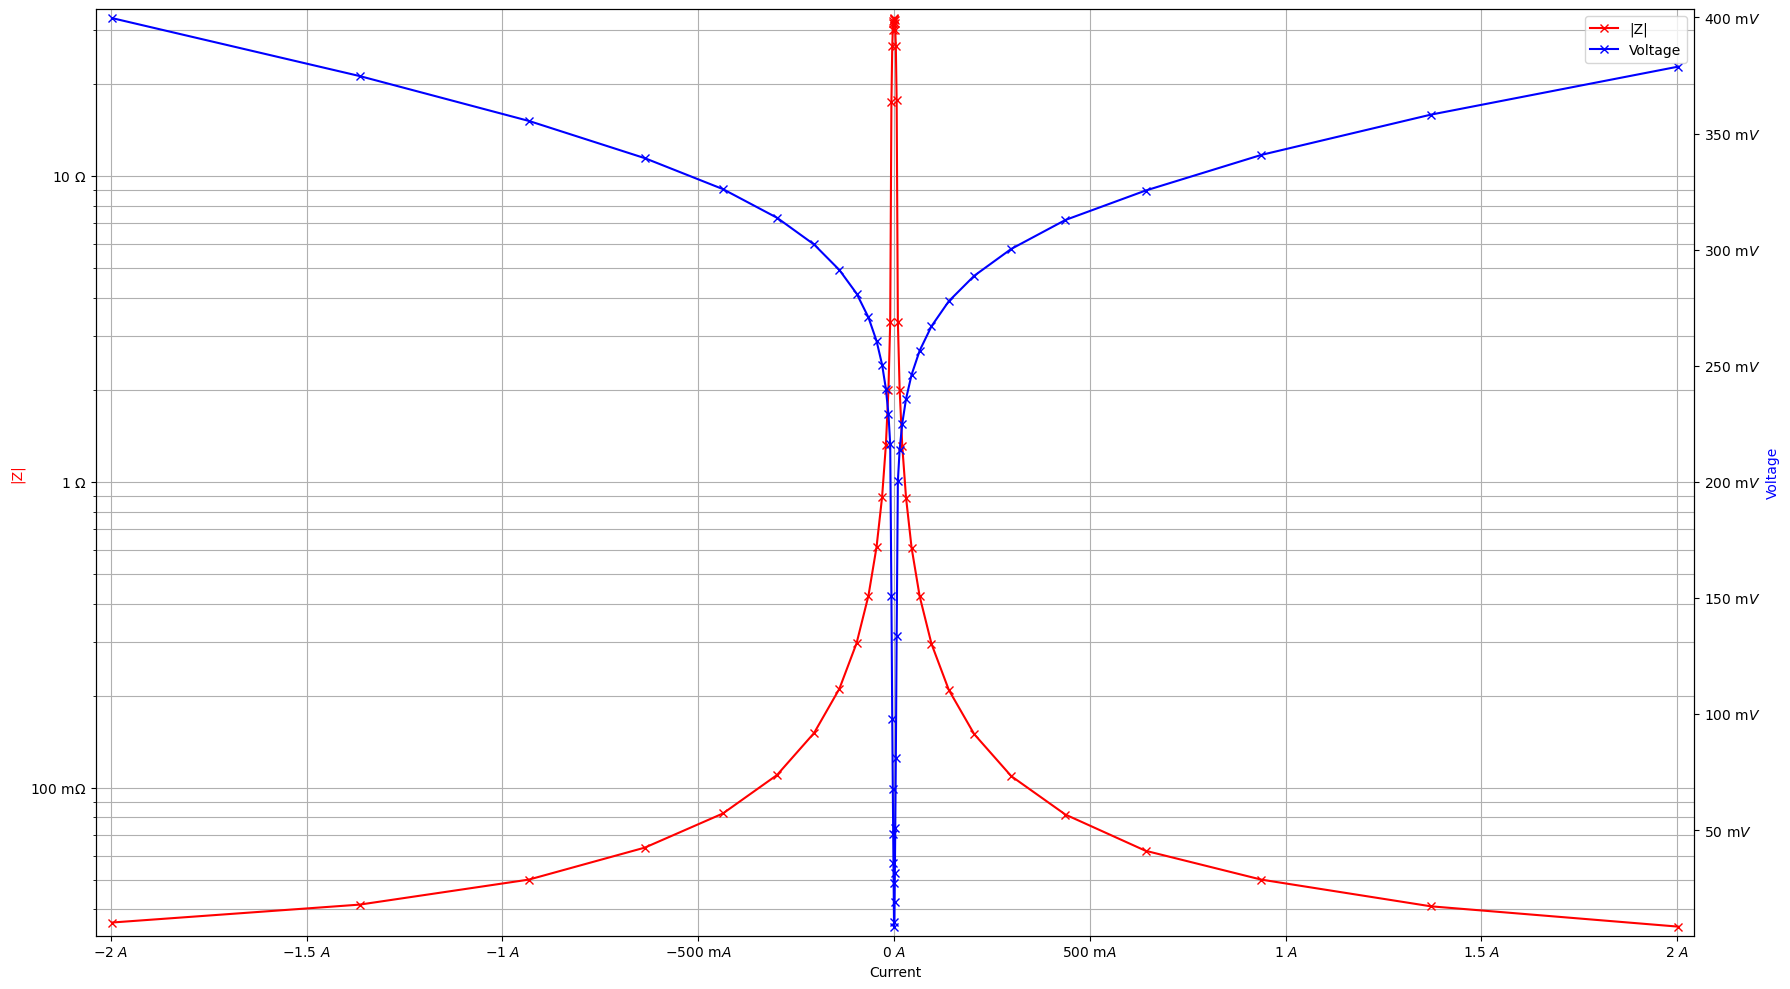

In [14]:
fig, (impedance_ax) = plt.subplots(
    1,
    1,
)
voltage_ax = impedance_ax.twinx()

(impedance_line,) = impedance_ax.semilogy(
    currents, np.absolute(impedances), marker="x", color="red", label="|Z|"
)
(voltage_line,) = voltage_ax.plot(
    currents, np.absolute(voltages), marker="x", color="blue", label="Voltage"
)

impedance_ax.yaxis.set_major_formatter(EngFormatter(unit=r"$\Omega$"))
impedance_ax.xaxis.set_major_formatter(EngFormatter(unit="$A$"))
impedance_ax.set_ylabel(r"|Z|")
impedance_ax.yaxis.label.set_color("red")
impedance_ax.set_xlabel(r"Current")

voltage_ax.yaxis.set_major_formatter(EngFormatter(unit=r"$V$"))
voltage_ax.xaxis.set_major_formatter(EngFormatter(unit="$A$"))
voltage_ax.set_ylabel(r"Voltage")
voltage_ax.yaxis.label.set_color("blue")
voltage_ax.set_xlabel(r"Current")

impedance_ax.grid(which="both")

impedance_ax.margins(0.01)
voltage_ax.margins(0.01)
voltage_ax.legend(handles=[impedance_line, voltage_line])

fig.set_size_inches(18, 10)
fig.tight_layout()
plt.show()